In [84]:
%load_ext autoreload
%autoreload 2

import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from optimal_market_maker_exchange_contract_drl import (
    Market,
    MarketMaker,
    Exchange,
    plot_controls,
    plot_incentives_vs_inventory,
    plot_optimal_volumes_vs_inventory,
)

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [168]:
z_bar = 2
plot_z_d = 0.05  # dark pool incentive (fixed for both sides)
n_points = 400

In [178]:
MODEL_NAME = "0.04_model"

PROJ_DIR = Path.cwd().parent
MODELS_DIR = PROJ_DIR / "saved_models" / "market_maker"
MODEL_DIR = MODELS_DIR / MODEL_NAME

print(f"Loading from: {MODEL_DIR}")
print(f"Contents:     {[p.name for p in sorted(MODEL_DIR.iterdir())]}")

Loading from: g:\My Drive\GoogleColab\optimal-market-maker-exchange-contract-drl\saved_models\market_maker\0.04_model
Contents:     ['best_model.pt', 'best_model_saved.pt', 'checkpoint_epoch_10000.pt', 'checkpoint_epoch_100000.pt', 'checkpoint_epoch_20000.pt', 'checkpoint_epoch_30000.pt', 'checkpoint_epoch_40000.pt', 'checkpoint_epoch_50000.pt', 'checkpoint_epoch_60000.pt', 'checkpoint_epoch_70000.pt', 'checkpoint_epoch_80000.pt', 'checkpoint_epoch_90000.pt', 'controls_2.0_0.05_-150.png', 'controls_2.0_0.05_-50.png', 'controls_2.0_0.05_0.png', 'controls_2.0_0.05_150.png', 'controls_2.0_0.05_50.png', 'loss.png', 'market_cfg.json', 'market_maker_cfg.json', 'train_mm_cfg.json', 'training.log']


In [181]:
LOAD_BEST = True

with open(MODEL_DIR / "market_cfg.json") as f:
    market_cfg = json.load(f)
with open(MODEL_DIR / "market_maker_cfg.json") as f:
    mm_cfg = json.load(f)
with open(MODEL_DIR / "train_mm_cfg.json") as f:
    train_cfg = json.load(f)

batch_size = train_cfg["batch_size"]
device = torch.device("cpu")

market = Market(**market_cfg, batch_size=batch_size)
market.to(device)

mm = MarketMaker(market=market, mm_cfg=mm_cfg, batch_size=batch_size)
mm.to(device)

# Load checkpoint
best_path = MODEL_DIR / "best_model.pt"
if LOAD_BEST and best_path.exists():
    ckpt_path = best_path
else:
    ckpts = sorted(
        glob.glob(str(MODEL_DIR / "checkpoint_epoch_*.pt")),
        key=lambda p: int(Path(p).stem.replace("checkpoint_epoch_", "")),
    )
    ckpt_path = Path(ckpts[-1])

epochs_trained, _, losses, best_loss = mm.load(path=ckpt_path, device=device)
mm.eval()

print(f"Loaded checkpoint: {ckpt_path.name}  ({epochs_trained} epochs)")

Loaded checkpoint: best_model.pt  (80903 epochs)


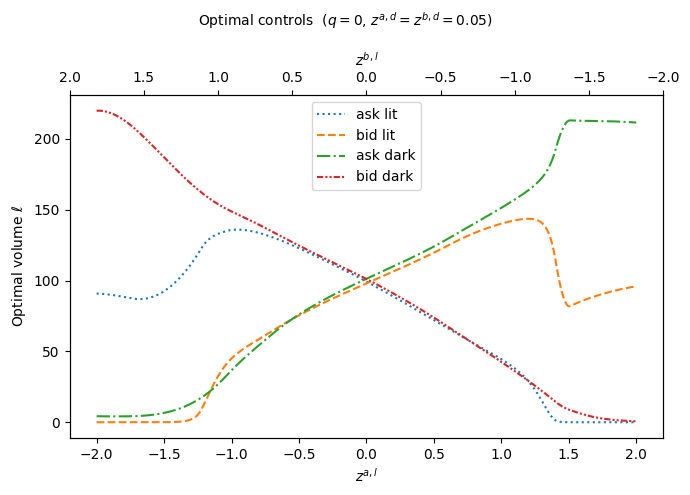

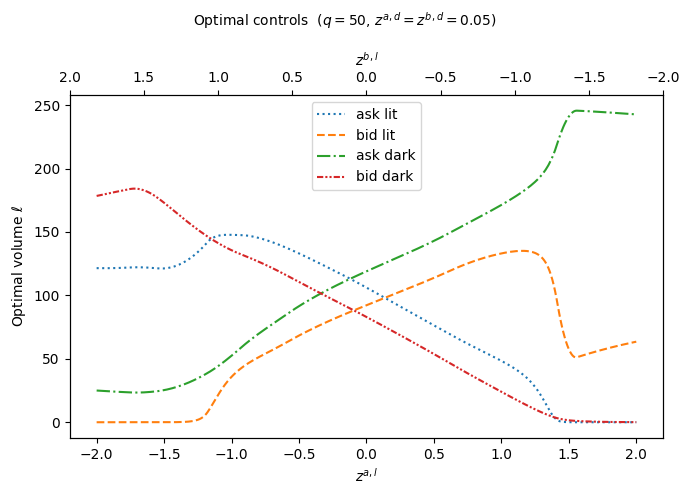

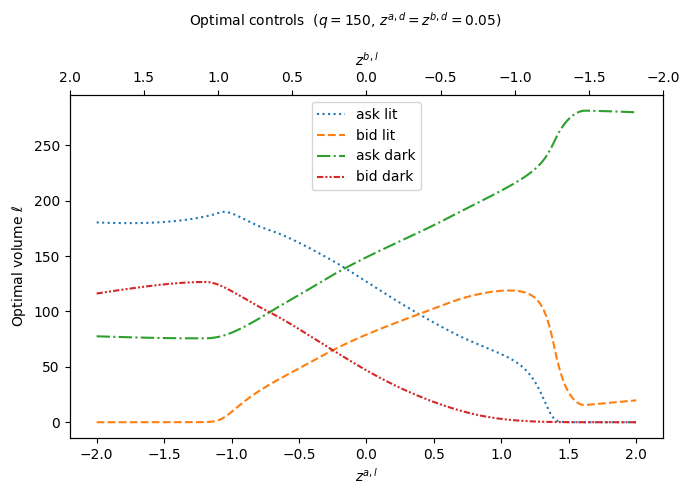

In [182]:
for q_val in [0, 50, 150]:
    fig_path = MODEL_DIR / f"controls_{mm.z_bar.item()}_{plot_z_d}_{q_val}.png"
    fig = plot_controls(mm, plot_q=q_val, plot_z_d=plot_z_d, save_path=fig_path)
    plt.show()

In [385]:
EXCHANGE_MODEL_NAME = "0.04_model"
LOAD_BEST_EXCHANGE = True

EXCHANGE_MODELS_DIR = PROJ_DIR / "saved_models" / "exchange"
EXCHANGE_MODEL_DIR = EXCHANGE_MODELS_DIR / EXCHANGE_MODEL_NAME

print(f"Loading from: {EXCHANGE_MODEL_DIR}")
print(f"Contents:     {[p.name for p in sorted(EXCHANGE_MODEL_DIR.iterdir())]}")

with open(EXCHANGE_MODEL_DIR / "exchange_cfg.json") as f:
    exchange_cfg = json.load(f)

exchange = Exchange(
    market=market, mm=mm, exchange_cfg=exchange_cfg, batch_size=batch_size
)
exchange.to(device)

# Load checkpoint
ex_best_path = EXCHANGE_MODEL_DIR / "best_model.pt"
if LOAD_BEST_EXCHANGE and ex_best_path.exists():
    ex_ckpt_path = ex_best_path
else:
    ex_ckpts = sorted(
        glob.glob(str(EXCHANGE_MODEL_DIR / "checkpoint_epoch_*.pt")),
        key=lambda p: int(Path(p).stem.replace("checkpoint_epoch_", "")),
    )
    ex_ckpt_path = Path(ex_ckpts[-1])

ex_epochs_trained, _, ex_losses, ex_best_loss = exchange.load(path=ex_ckpt_path, device=device)
exchange.eval()

print(f"Loaded checkpoint: {ex_ckpt_path.name}  ({ex_epochs_trained} epochs)")

Loading from: g:\My Drive\GoogleColab\optimal-market-maker-exchange-contract-drl\saved_models\exchange\0.04_model
Contents:     ['best_model.pt', 'checkpoint_epoch_100.pt', 'checkpoint_epoch_1000.pt', 'checkpoint_epoch_1050.pt', 'checkpoint_epoch_1100.pt', 'checkpoint_epoch_1150.pt', 'checkpoint_epoch_1200.pt', 'checkpoint_epoch_1250.pt', 'checkpoint_epoch_1300.pt', 'checkpoint_epoch_1350.pt', 'checkpoint_epoch_1400.pt', 'checkpoint_epoch_1450.pt', 'checkpoint_epoch_150.pt', 'checkpoint_epoch_1500.pt', 'checkpoint_epoch_1550.pt', 'checkpoint_epoch_1600.pt', 'checkpoint_epoch_1650.pt', 'checkpoint_epoch_1700.pt', 'checkpoint_epoch_1750.pt', 'checkpoint_epoch_1800.pt', 'checkpoint_epoch_1850.pt', 'checkpoint_epoch_1900.pt', 'checkpoint_epoch_1950.pt', 'checkpoint_epoch_200.pt', 'checkpoint_epoch_2000.pt', 'checkpoint_epoch_2050.pt', 'checkpoint_epoch_2100.pt', 'checkpoint_epoch_2150.pt', 'checkpoint_epoch_2200.pt', 'checkpoint_epoch_2250.pt', 'checkpoint_epoch_2300.pt', 'checkpoint_epoch

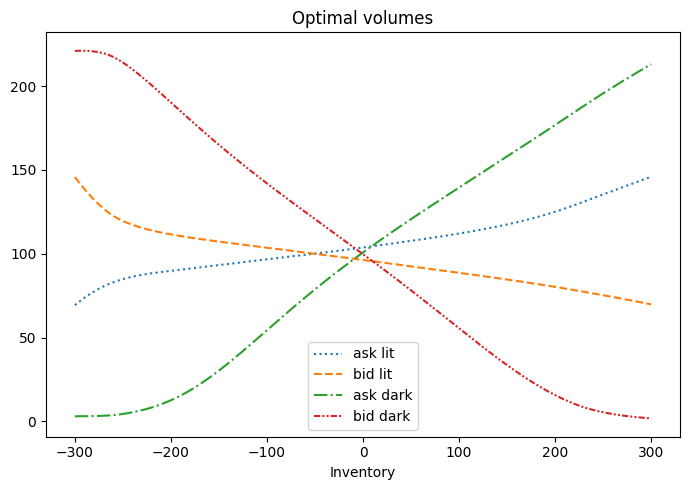

In [386]:
step = 999

fig = plot_optimal_volumes_vs_inventory(
    exchange, step=step, save_path=EXCHANGE_MODEL_DIR / "optimal_volumes.png"
)
plt.show()

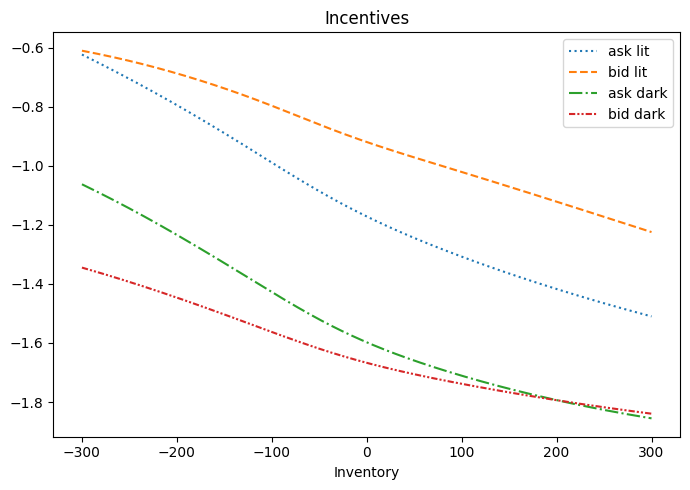

In [387]:
fig = plot_incentives_vs_inventory(
    exchange, step=step, save_path=EXCHANGE_MODEL_DIR / "incentives.png"
)
plt.show()